# Principal Component Analysis (PCA)

Principal Component Analysis is applied to project the high-dimensional symbolic music data into a lower-dimensional space for visualization and exploratory analysis.


In [1]:
import pandas as pd
from pathlib import Path

DATA_RAW = Path("../data/raw").resolve()

csv_file = DATA_RAW / "Turkish maqam music pieces in time series format_3000 rows x 365 columns.csv"

df = pd.read_csv(csv_file)

X = df.iloc[:, 1:]

print("Shape:", X.shape)

Shape: (3000, 365)


In [2]:
X_filled = X.fillna(X.mean())

print("Missing values before:", X.isnull().sum().sum())
print("Missing values after :", X_filled.isnull().sum().sum())

Missing values before: 20293
Missing values after : 0


In [3]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_filled)

print("Scaled shape:", X_scaled.shape)

Scaled shape: (3000, 365)


In [4]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print("PCA shape:", X_pca.shape)
print("Explained variance ratio:", pca.explained_variance_ratio_)
print("Total explained variance:", pca.explained_variance_ratio_.sum())

PCA shape: (3000, 2)
Explained variance ratio: [0.13755527 0.05138417]
Total explained variance: 0.18893943695063492


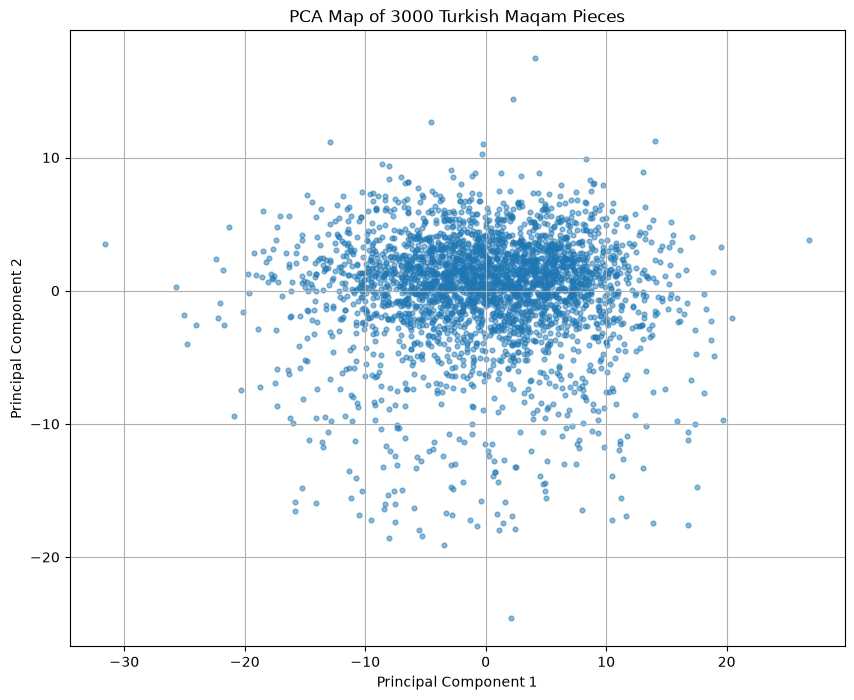

In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))

plt.scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.5, s=12)

plt.title("PCA Map of 3000 Turkish Maqam Pieces")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.grid(True)

plt.show()

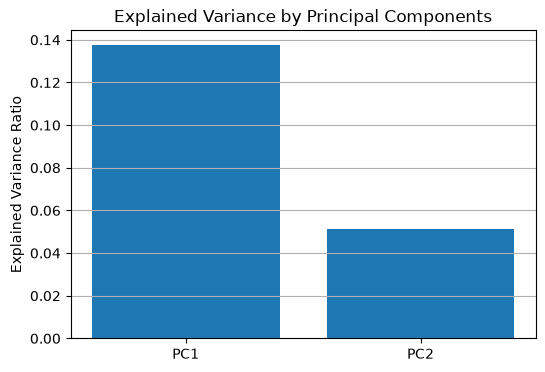

In [6]:
plt.figure(figsize=(6, 4))

plt.bar(["PC1", "PC2"], pca.explained_variance_ratio_)

plt.title("Explained Variance by Principal Components")
plt.ylabel("Explained Variance Ratio")
plt.grid(axis="y")

plt.show()

In [7]:
DATA_PROCESSED = Path("../data/processed").resolve()
DATA_PROCESSED.mkdir(parents=True, exist_ok=True)

pca_df = pd.DataFrame({
    "ID": df["ID"],
    "PC1": X_pca[:, 0],
    "PC2": X_pca[:, 1]
})

output_file = DATA_PROCESSED / "pca_results.csv"

pca_df.to_csv(output_file, index=False)

print("Saved to:", output_file)

Saved to: C:\Users\tualtan\Projects\SymbTr-Analysis-Book\webbook\data\processed\pca_results.csv
